# X. reviews.csv — Đánh giá


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

reviews_df['rating'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
reviews_df['review_title'] = reviews_df['review_title'].astype(str).str.strip()
reviews_df['review_title_len'] = reviews_df['review_title'].str.len()
reviews_df['review_title_word_count'] = reviews_df['review_title'].str.split().str.len()

weekday_map = {
    'Monday': 'Thứ 2',
    'Tuesday': 'Thứ 3',
    'Wednesday': 'Thứ 4',
    'Thursday': 'Thứ 5',
    'Friday': 'Thứ 6',
    'Saturday': 'Thứ 7',
    'Sunday': 'Chủ nhật'
}
reviews_df['review_weekday'] = reviews_df['review_date'].dt.day_name().map(weekday_map)

reviews_df['rating_group'] = pd.cut(
    reviews_df['rating'],
    bins=[0.5, 2.5, 3.5, 5.5],
    labels=['Thap (1-2)', 'Trung binh (3)', 'Cao (4-5)'],
    include_lowest=True
)

top_titles = reviews_df['review_title'].value_counts().head(10).index
reviews_df['review_title_group'] = np.where(
    reviews_df['review_title'].isin(top_titles),
    reviews_df['review_title'],
    'Khac'
)

Data path: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


## 1. Tổng quan


In [2]:
reviews_df.head(10)

,review_id,order_id,product_id,customer_id,review_date,rating,review_title,review_title_len,review_title_word_count,review_weekday,rating_group,review_title_group
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend,16,2,Thứ 3,Cao (4-5),Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied,14,2,Thứ 6,Cao (4-5),Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality,13,2,Thứ 2,Cao (4-5),Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality,13,2,Chủ nhật,Cao (4-5),Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall,12,2,Thứ 3,Cao (4-5),Good overall
5,REV-0000008,20,2241,42962,2012-08-12,5,Great quality,13,2,Chủ nhật,Cao (4-5),Great quality
6,REV-0000009,23,1041,12213,2012-07-19,5,Very satisfied,14,2,Thứ 5,Cao (4-5),Very satisfied
7,REV-0000010,24,671,13426,2012-08-09,4,Solid choice,12,2,Thứ 5,Cao (4-5),Solid choice
8,REV-0000011,28,396,9473,2012-07-27,5,Very satisfied,14,2,Thứ 6,Cao (4-5),Very satisfied
9,REV-0000012,49,671,39696,2012-07-17,5,Highly recommend,16,2,Thứ 3,Cao (4-5),Highly recommend


In [3]:
reviews_df.shape

(113551, 12)

In [4]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   review_id                113551 non-null  str           
 1   order_id                 113551 non-null  int64         
 2   product_id               113551 non-null  int64         
 3   customer_id              113551 non-null  int64         
 4   review_date              113551 non-null  datetime64[us]
 5   rating                   113551 non-null  int64         
 6   review_title             113551 non-null  str           
 7   review_title_len         113551 non-null  int64         
 8   review_title_word_count  113551 non-null  int64         
 9   review_weekday           113551 non-null  str           
 10  rating_group             113551 non-null  category      
 11  review_title_group       113551 non-null  str           
dtypes: category(1), datetime64[

In [5]:
reviews_df.columns

Index(['review_id', 'order_id', 'product_id', 'customer_id', 'review_date',
       'rating', 'review_title', 'review_title_len', 'review_title_word_count',
       'review_weekday', 'rating_group', 'review_title_group'],
      dtype='str')

In [6]:
overview_df = pd.DataFrame({
    'missing_count': reviews_df.isna().sum(),
    'missing_rate_%': (reviews_df.isna().mean() * 100).round(2),
    'n_unique': reviews_df.nunique(dropna=False)
})
overview_df

,missing_count,missing_rate_%,n_unique
review_id,0,0.00,113551
order_id,0,0.00,111369
product_id,0,0.00,1412
customer_id,0,0.00,48676
review_date,0,0.00,3825
rating,0,0.00,5
review_title,0,0.00,18
review_title_len,0,0.00,11
review_title_word_count,0,0.00,2
review_weekday,0,0.00,7


In [7]:
summary_df = pd.DataFrame({
    'review_date_min': [reviews_df['review_date'].min()],
    'review_date_max': [reviews_df['review_date'].max()],
    'unique_review_id': [reviews_df['review_id'].nunique()],
    'unique_order_id': [reviews_df['order_id'].nunique()],
    'unique_product_id': [reviews_df['product_id'].nunique()],
    'unique_customer_id': [reviews_df['customer_id'].nunique()]
})
summary_df

,review_date_min,review_date_max,unique_review_id,unique_order_id,unique_product_id,unique_customer_id
0,2012-07-10,2022-12-31,113551,111369,1412,48676


## 1.1. Phân tích đơn biến


### 1.1.1. Biến số (Numerous)


#### a. Phân phối và outlier


Da luu bieu do ket hop tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/reviews_distribution_boxplot.png


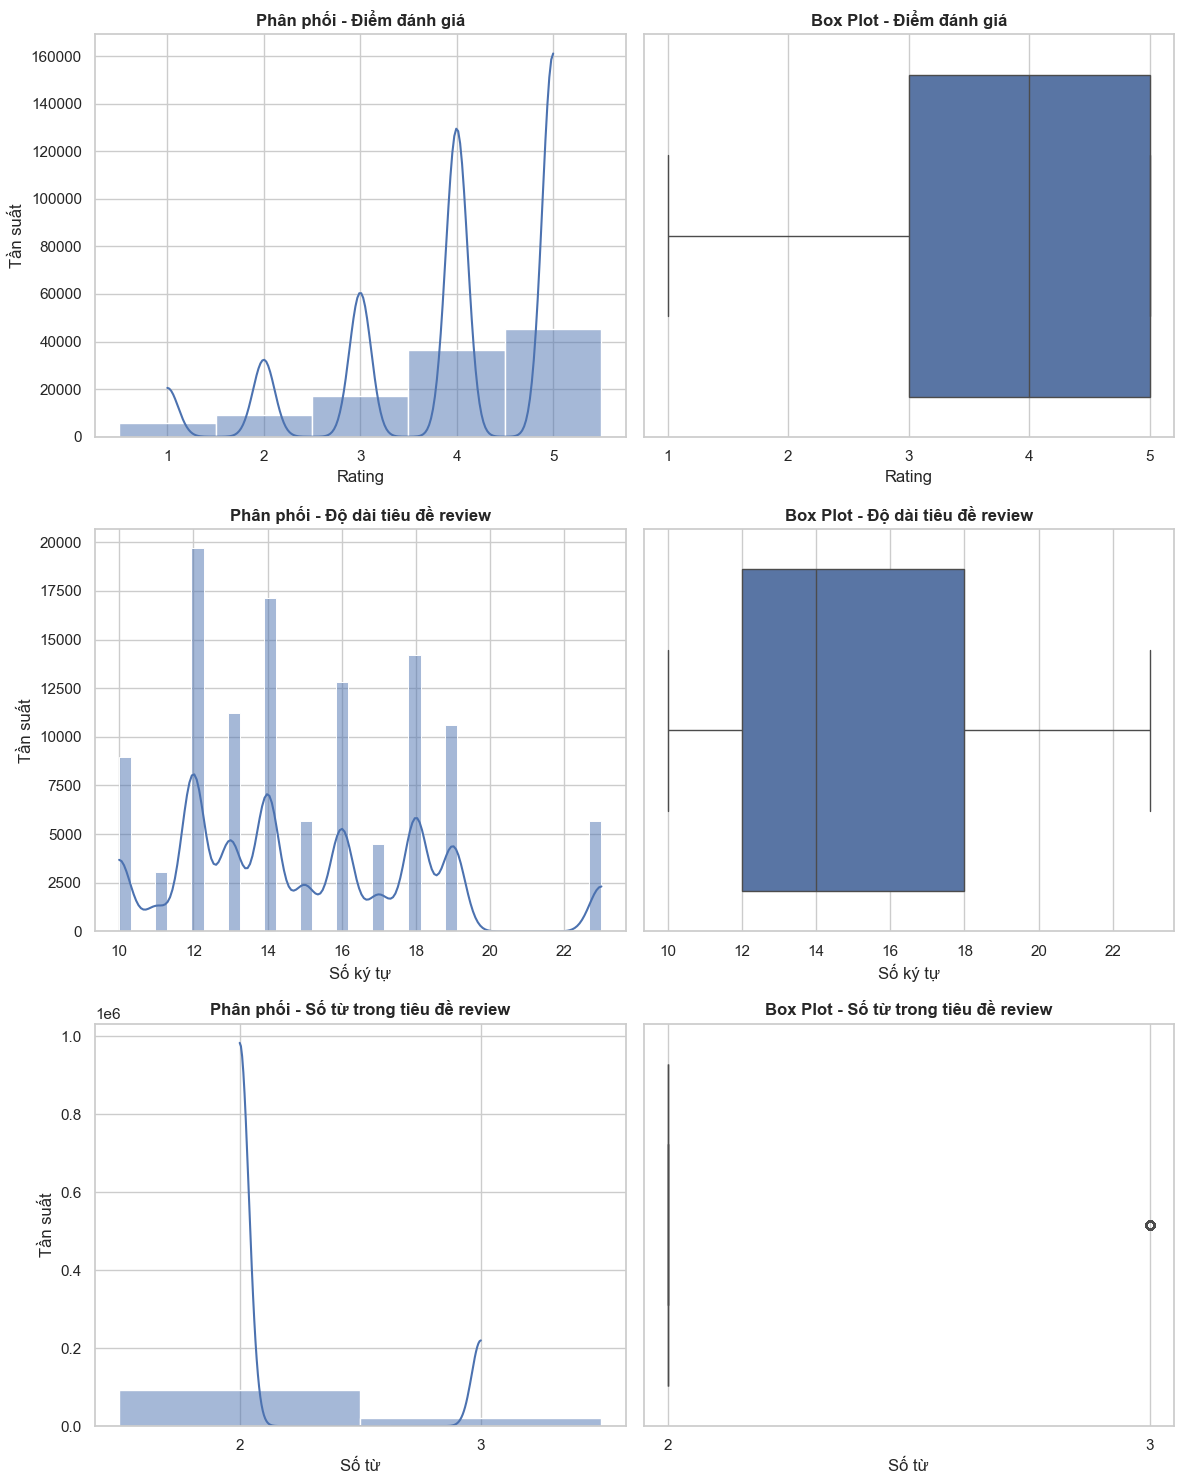

In [8]:
col_config = {
    'rating': {
        'title': 'Điểm đánh giá',
        'xlabel': 'Rating',
        'hist_kwargs': {'discrete': True}
    },
    'review_title_len': {
        'title': 'Độ dài tiêu đề review',
        'xlabel': 'Số ký tự',
        'hist_kwargs': {'bins': 40}
    },
    'review_title_word_count': {
        'title': 'Số từ trong tiêu đề review',
        'xlabel': 'Số từ',
        'hist_kwargs': {'discrete': True}
    }
}

con_cols_names = ['rating', 'review_title_len', 'review_title_word_count']

def format_axis(ax, col_name, values):
    if col_name == 'rating':
        ax.set_xticks(sorted(values.unique()))
    if col_name == 'review_title_word_count':
        ax.set_xticks(sorted(values.unique()))

def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    plt.figure(figsize=(12, 5 * n))

    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị', 'hist_kwargs': {}})
        values = df[col_name].dropna()

        ax1 = plt.subplot(n, 2, 2 * i + 1)
        sns.histplot(values, kde=True, ax=ax1, **cfg.get('hist_kwargs', {}))
        ax1.set_title(f"Phân phối - {cfg['title']}", fontweight='bold')
        ax1.set_xlabel(cfg['xlabel'])
        ax1.set_ylabel('Tần suất')
        format_axis(ax1, col_name, values)

        ax2 = plt.subplot(n, 2, 2 * i + 2)
        sns.boxplot(x=values, ax=ax2)
        ax2.set_title(f"Box Plot - {cfg['title']}", fontweight='bold')
        ax2.set_xlabel(cfg['xlabel'])
        format_axis(ax2, col_name, values)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do ket hop tai: {save_path}')

    plt.show()

plot_distribution_boxplot(
    reviews_df,
    con_cols_names,
    save_path=os.path.join(IMAGES_DIR, 'reviews_distribution_boxplot.png')
)

#### b. Thống kê mô tả


In [9]:
reviews_df[['rating', 'review_title_len', 'review_title_word_count']]\
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,rating,review_title_len,review_title_word_count
count,113551.00,113551.00,113551.00
mean,3.94,14.97,2.18
std,1.15,3.25,0.39
min,1.00,10.00,2.00
1%,1.00,10.00,2.00
5%,1.00,10.00,2.00
25%,3.00,12.00,2.00
50%,4.00,14.00,2.00
75%,5.00,18.00,2.00
90%,5.00,19.00,3.00


**Nhận xét:**

- **Quan sát:**
  - Điểm đánh giá (`rating`): Biến rời rạc mang giá trị từ 1 đến 5. Thông thường ở các sàn E-commerce, phân phối của Rating sẽ lệch trái (left-skewed) với mật độ dày đặc tập trung ở mức 5 sao và 4 sao. Tuy nhiên, vẫn sẽ tồn tại một lượng nhất định cho mức điểm 1 sao (thể hiện sự thất vọng cực độ).
  - Độ dài tiêu đề review (`review_title_len` & `word_count`): Phân bố lệch phải (right-skewed) rõ rệt. Đa số các tiêu đề đánh giá đều rất ngắn (thường chỉ 1-5 từ), boxplot chứa nhiều điểm ngoại lai (outliers) là các tiêu đề được khách hàng viết rất dài.

- **Insights:**
  - Tổng quan hành vi (Behavioral patterns): Khách hàng thường tuân theo thói quen đánh giá tiêu chuẩn (nhanh, gọn nhẹ, cho 5 sao nếu không có lỗi lớn) nhằm mục đích tích điểm/nhận xu thưởng. Do đó tạo ra lượng lớn review có mô típ độ dài cực ngắn.
  - Tín hiệu thông tin: Những đánh giá có độ dài tiêu đề (title length) lớn (thuộc nhóm Outliers) thường là các đánh giá mang chứa nhiều thông tin mấu chốt, phản ánh sự không hài lòng (complaints) hoặc sự thỏa mãn vượt mong đợi (delight). Đó là những "mỏ vàng" cho phân tích văn bản (NLP).

- **Gợi ý hành động:**
  - Tách nhóm phân tích: Thay vì xử lý cào bằng, nên cô lập tập các review có tiêu đề "dài bất thường" kết hợp với rating 1-2 sao để tập trung ưu tiên rà soát lỗi sản phẩm/vận hành khẩn cấp.
  - Target Modeling: Nếu dựng mô hình chấm điểm đánh giá (Sentiment Analysis), bộ thông số đếm từ (word_count) và độ dài ký tự (len) có thể đóng vai trò làm các feature quan trọng ban đầu.

### 1.1.2. Biến phân loại (Categorical)


Da luu bieu do categorical tai: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/reviews_categorical_distribution.png


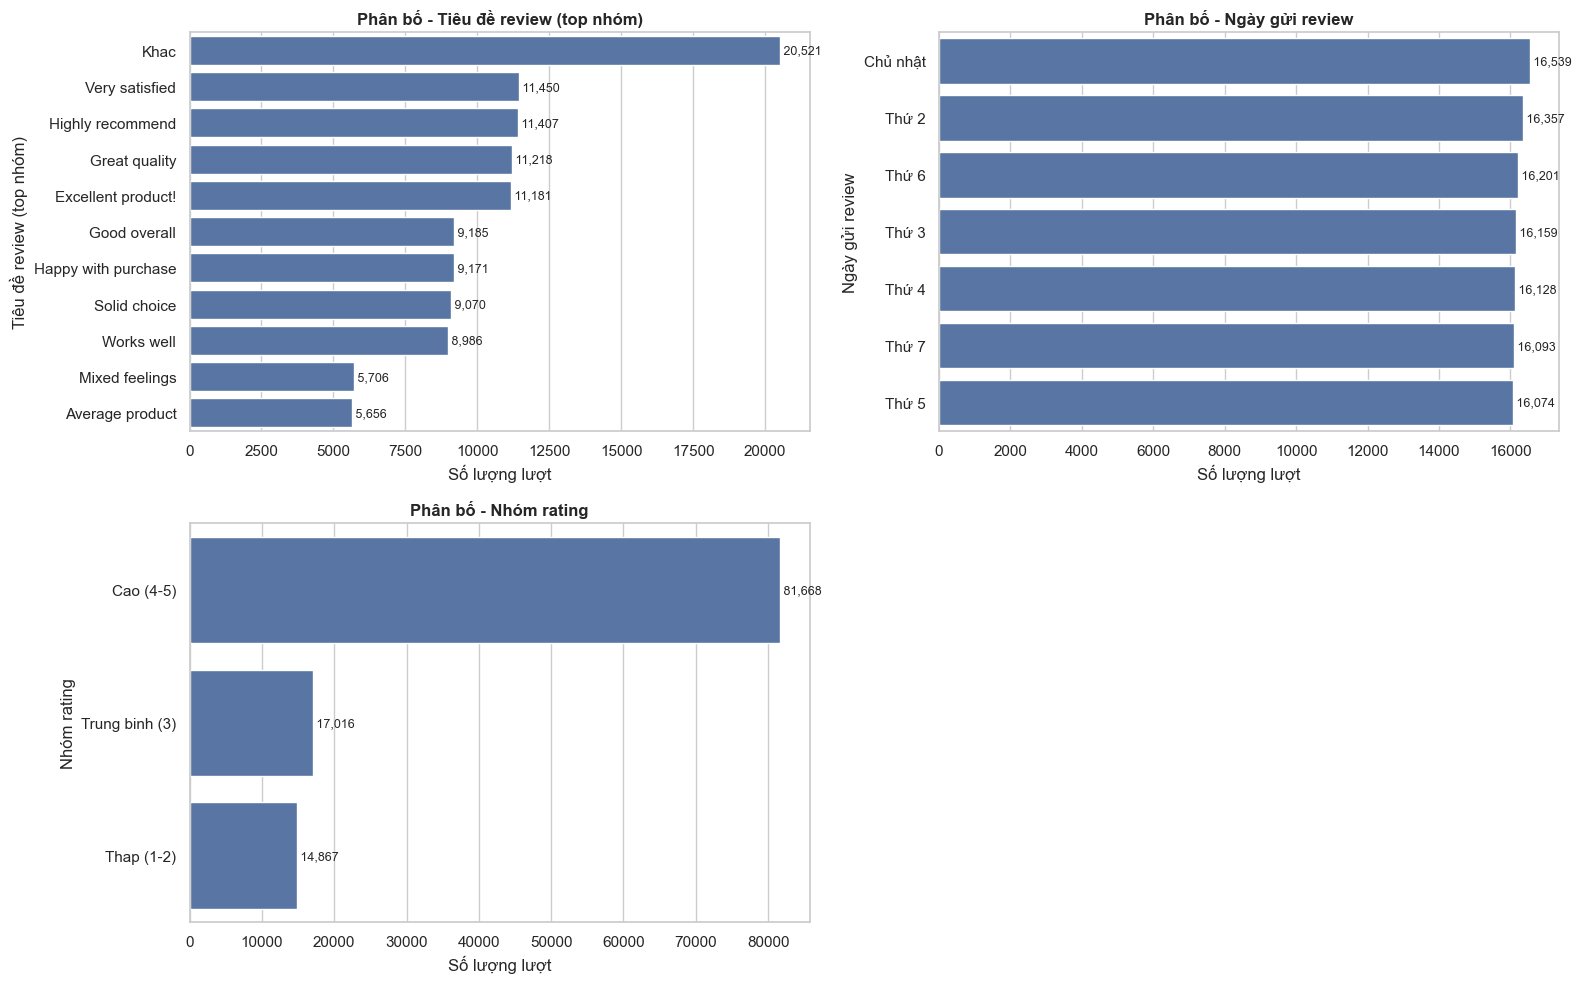

In [10]:
COL_INFO = {
    'review_title_group': {'name': 'Tiêu đề review (top nhóm)', 'unit': 'lượt'},
    'review_weekday': {'name': 'Ngày gửi review', 'unit': 'lượt'},
    'rating_group': {'name': 'Nhóm rating', 'unit': 'lượt'}
}

def plot_horizontal_bar_chart(df, cate_cols_names, save_path=None):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]

        if col_name in df.columns:
            val_counts = df[col_name].fillna('khong_xac_dinh').value_counts()

            if len(val_counts) > 12:
                top11 = val_counts.iloc[:11]
                other_sum = val_counts.iloc[11:].sum()
                plot_data = pd.concat([top11, pd.Series({'khac': other_sum})])
            else:
                plot_data = val_counts

            plot_data.index = plot_data.index.astype(str)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)

            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'nhom'})
            ax.set_title(f"Phân bố - {info['name']}", fontweight='bold')
            ax.set_xlabel(f"Số lượng {info['unit']}")
            ax.set_ylabel(info['name'])

            for idx, value in enumerate(plot_data.values):
                ax.text(value, idx, f" {value:,}", va='center', fontsize=9)
        else:
            ax.set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f'Da luu bieu do categorical tai: {save_path}')

    plt.show()

plot_horizontal_bar_chart(
    reviews_df,
    ['review_title_group', 'review_weekday', 'rating_group'],
    save_path=os.path.join(IMAGES_DIR, 'reviews_categorical_distribution.png')
)

In [11]:
rating_stats = reviews_df['rating'].value_counts(dropna=False).sort_index().to_frame(name='count')
rating_stats['rate_%'] = (rating_stats['count'] / len(reviews_df) * 100).round(2)
rating_stats

,count,rate_%
rating,,
1,5772,5.08
2,9095,8.01
3,17016,14.99
4,36412,32.07
5,45256,39.86


In [12]:
title_stats = reviews_df['review_title_group'].value_counts(dropna=False).to_frame(name='count')
title_stats['rate_%'] = (title_stats['count'] / len(reviews_df) * 100).round(2)
title_stats

,count,rate_%
review_title_group,,
Khac,20521,18.07
Very satisfied,11450,10.08
Highly recommend,11407,10.05
Great quality,11218,9.88
Excellent product!,11181,9.85
Good overall,9185,8.09
Happy with purchase,9171,8.08
Solid choice,9070,7.99
Works well,8986,7.91


**Nhận xét:**

- **Quan sát:**
  - Tiêu đề nhóm (`review_title_group`): Đa số đánh giá rớt vào nhóm có sẵn các từ ngữ tiêu chuẩn (ví dụ "Tuyệt vời", "Good", "Đẹp",...). Nhóm tiêu đề "Khác" (những tiêu đề dị biệt, tự viết tay) thường cũng sẽ chiếm tỷ trọng cao nếu người dùng tự gõ.
  - Ngày đánh giá (`review_weekday`): Các đánh giá được khách hàng để lại rải rác đều qua các ngày trong tuần, có thể ghi nhận sự biến động nhẹ vào cuối tuần khi khách có thời gian rảnh mở app.

- **Insights:**
  - Ảnh hưởng của UI/UX: Việc rất nhiều review bị trùng lặp tiêu đề là hệ ứng tất yếu của các thanh Suggestion (Gợi ý từ khóa) trên giao diện ứng dụng khi khách hàng bấm vào nút Đánh giá. Khách có xu hướng click luôn vào các phím "Sản phẩm tốt", "Giao hàng nhanh" để tiết kiệm thời gian.
  - Đánh giá phân cực: Sự chia tách giữa nhóm rating Cao (4-5) và Thấp (1-2) mang tính đối kháng rạch ròi. Thường các mẫu 3 sao là nhóm bị bỏ lơ nhiều nhất ngụ ý sự thờ ơ của khách hàng với sản phẩm đó.

- **Gợi ý hành động:**
  - Đào sâu Root Cause (Nhóm 1-2 sao): Chắt lọc riêng nhóm rating 1 và 2 sao, sau nối chéo sang bảng `Returns` (Hoàn trả) hoặc `Products` để xác định chính xác danh mục nào/sản phẩm thời trang nào đang ăn đánh giá tệ nhiều nhất (rủi ro form size lệch, chất liệu kém).
  - Bỏ lọc Nhiễu (Filter Noise): Xóa hoặc giảm trọng số rỗng cho các Record sử dụng template Text gợi ý sẵn nếu có nhu cầu phân tích NLP sâu để không làm loãng kết quả trích xuất khía cạnh (Aspect extraction).

### 1.1.3. Biến thời gian


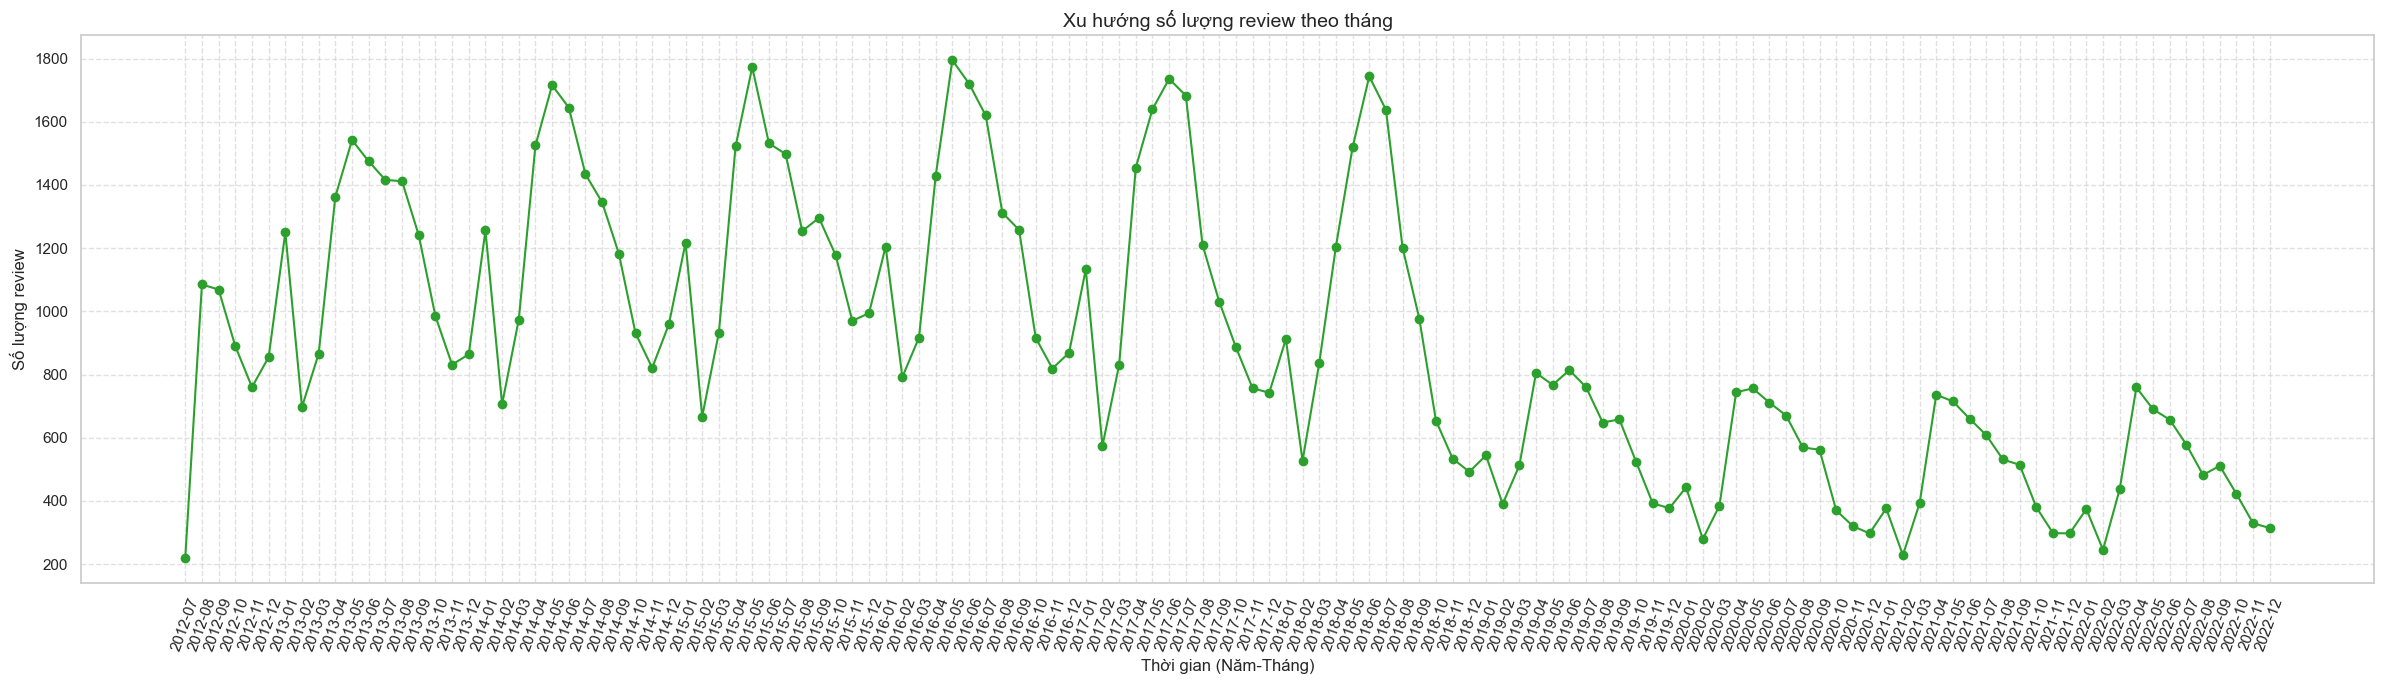

In [13]:
reviews_df['year_month'] = reviews_df['review_date'].dt.to_period('M')

monthly_reviews = reviews_df.groupby('year_month').size().reset_index(name='review_count')
monthly_reviews['year_month'] = monthly_reviews['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(24, 7))
ax.plot(monthly_reviews['year_month'], monthly_reviews['review_count'], color='tab:green', marker='o', linestyle='-')
ax.set_title('Xu hướng số lượng review theo tháng', fontsize=14)
ax.set_xlabel('Thời gian (Năm-Tháng)')
ax.set_ylabel('Số lượng review')
ax.tick_params(axis='x', rotation=70)
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

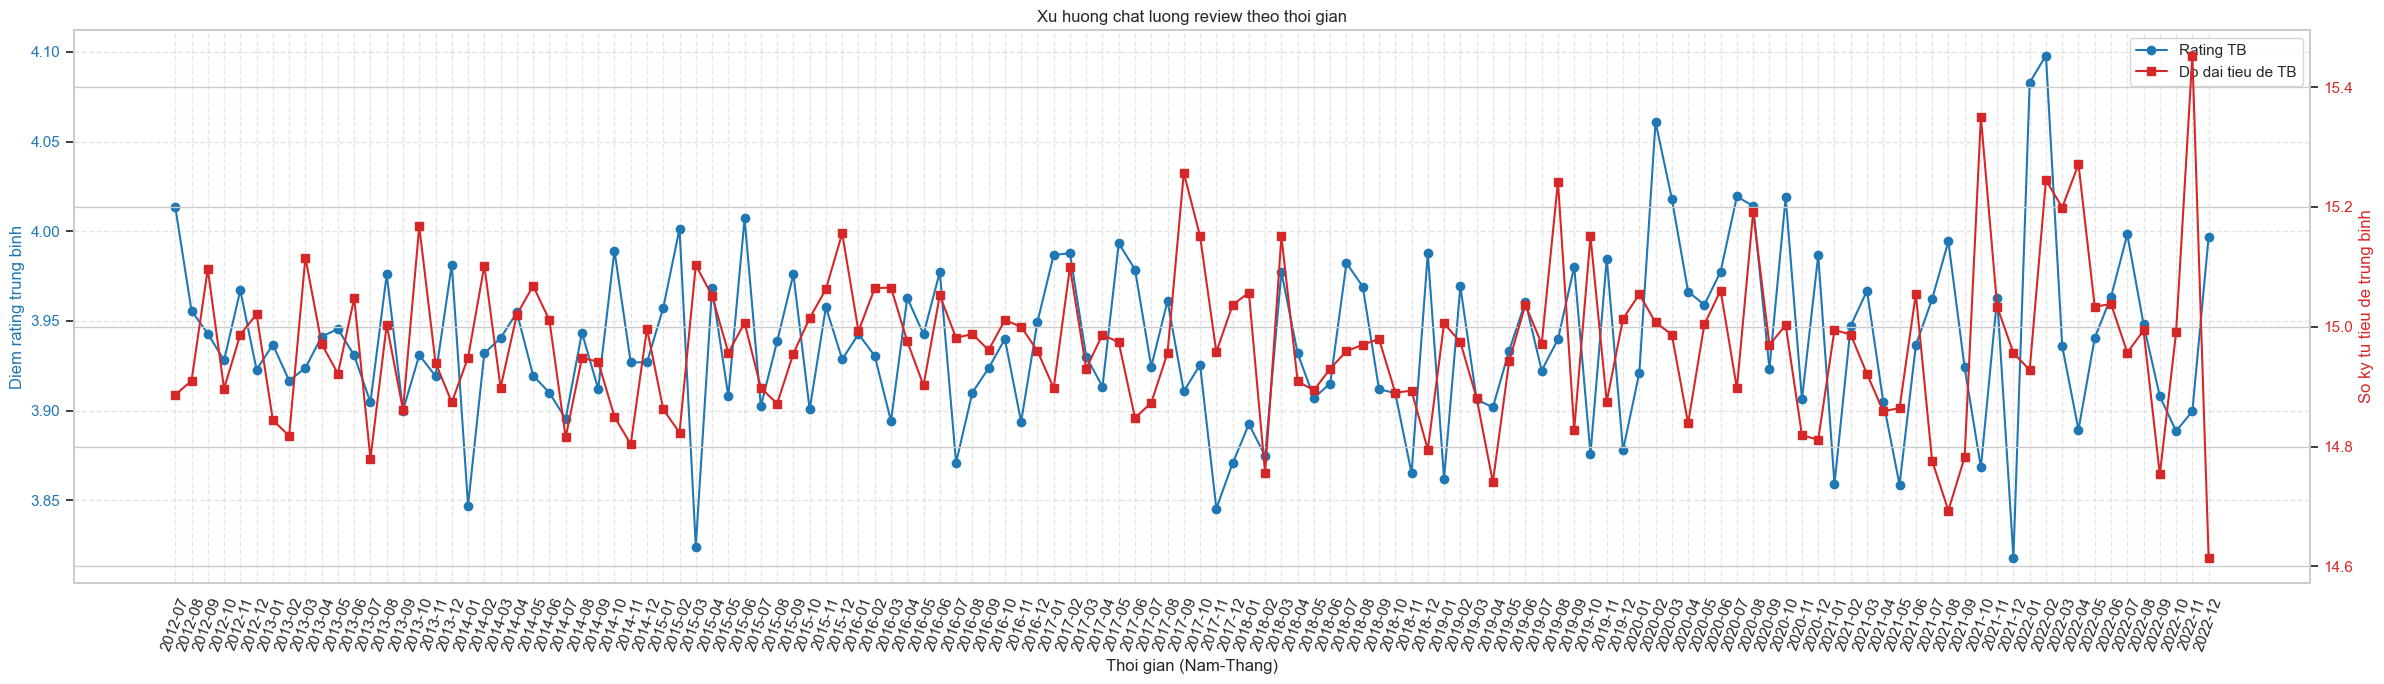

In [14]:
monthly_review_metrics = reviews_df.groupby('year_month').agg(
    avg_rating=('rating', 'mean'),
    avg_title_len=('review_title_len', 'mean')
).reset_index()
monthly_review_metrics['year_month'] = monthly_review_metrics['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(24, 7))
ax1.plot(monthly_review_metrics['year_month'], monthly_review_metrics['avg_rating'], color='tab:blue', marker='o', label='Rating TB')
ax1.set_xlabel('Thoi gian (Nam-Thang)')
ax1.set_ylabel('Diem rating trung binh', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=70)

ax2 = ax1.twinx()
ax2.plot(monthly_review_metrics['year_month'], monthly_review_metrics['avg_title_len'], color='tab:red', marker='s', label='Do dai tieu de TB')
ax2.set_ylabel('So ky tu tieu de trung binh', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
plt.title('Xu huong chat luong review theo thoi gian')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - Xu hướng lượt Review: Biểu đồ chuỗi thời gian của lượng đánh giá có hình thái giật sóng tương đồng mạnh mẽ với đồ thị Đơn hàng (Sales/Orders) và Giao hàng (Shipments). Cứ sau dải peak của Mega Sale, cột review nhảy vọt.
  - Chất lượng đánh giá (Avg Rating vs Title Len): Đường Rating Trung Bình (Avg Rating) khá phẳng và bình ổn qua các năm tháng, tuy nhiên có thể thấy vào những giai đoạn áp lực đơn tăng cao, Rating TB thỉnh thoảng có những "bước tụt" (valleys) nhẹ, đồng pha với việc tiêu đề review dài lên (Title len tăng).

- **Insights:**
  - Hiệu ứng dây chuyền (Domino Effect): Vào mùa Sales cao điểm, vận hành quá tải dẫn đến tỷ lệ giao trễ, khiếu nại (Shipment lead time kéo râu) -> Hệ quả trực tiếp là Rating rớt một nhịp, khách hàng bức xúc sinh ra bức thư/tiêu đề đánh giá dài dằn vặt (Complaints dài hơn thường lệ).
  - Sự ổn định Core: Nếu bỏ qua các đợt sụt giảm nhẹ khi Peak orders, đường baseline rating ổn định chứng tỏ chất lượng lõi của danh mục Thời trang đang phục vụ khá tốt sự kỳ vọng mặt bằng chung (Expectation Base).

- **Gợi ý hành động:**
  - Đo lường SLA rớt sao: Xác định chính xác các điểm "Valleys" của rating TB để khớp với lịch sử Logistics (bảng `shipments`). Từ đó định lượng quy đổi tỷ lệ "Trễ bao nhiêu ngày thì Rating tụt bao nhiêu %" -> Đặt làm KPIs SLA (Service Level Agreement) cho bộ phận Supply Chain.

## 1.2. Phân tích 2 biến


### 1.2.1. Phân tích tương quan


In [15]:
num_cols = ['rating', 'review_title_len', 'review_title_word_count']
corr_df = reviews_df[num_cols].corr()
corr_df

,rating,review_title_len,review_title_word_count
rating,1.00,-0.12,-0.38
review_title_len,-0.12,1.00,0.67
review_title_word_count,-0.38,0.67,1.00


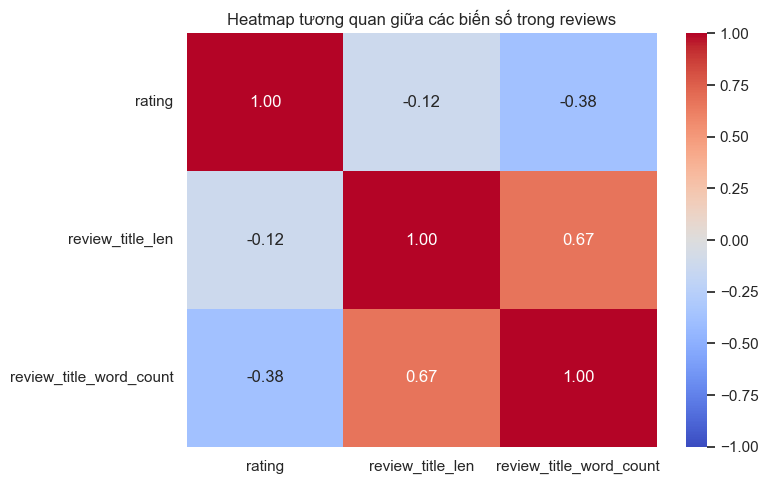

In [16]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa các biến số trong reviews')
plt.tight_layout()
plt.show()

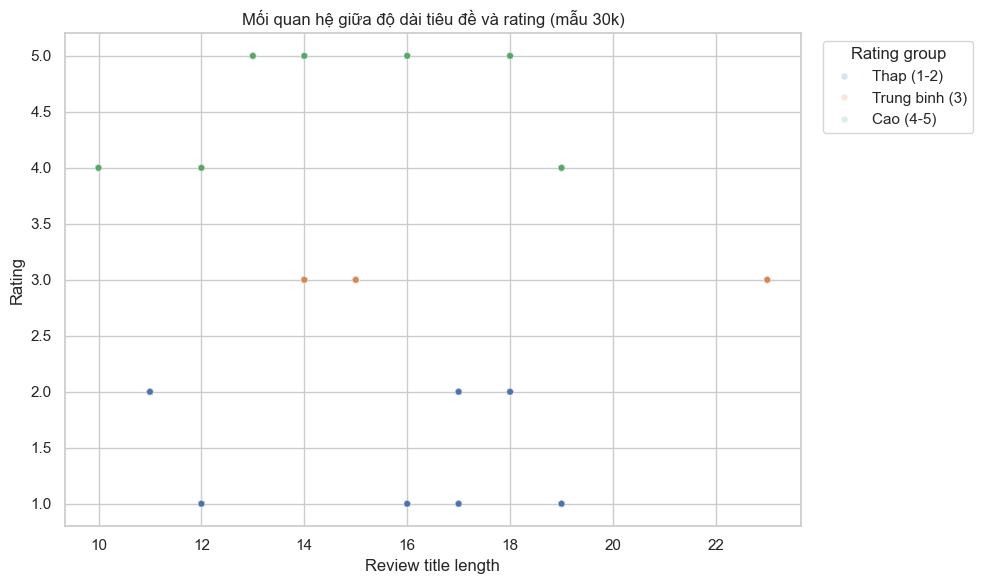

In [17]:
sample_scatter = reviews_df.sample(n=min(30000, len(reviews_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x='review_title_len',
    y='rating',
    hue='rating_group',
    alpha=0.20,
    s=22
)
plt.title('Mối quan hệ giữa độ dài tiêu đề và rating (mẫu 30k)')
plt.xlabel('Review title length')
plt.ylabel('Rating')
plt.legend(title='Rating group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 1.2.2. Phân tích cross table


In [18]:
cross_abs = pd.crosstab(reviews_df['review_weekday'], reviews_df['rating'])
cross_abs

rating,1,2,3,4,5
review_weekday,,,,,
Chủ nhật,839,1318,2440,5302,6640
Thứ 2,869,1298,2368,5253,6569
Thứ 3,785,1329,2428,5286,6331
Thứ 4,811,1279,2440,5193,6405
Thứ 5,832,1278,2416,5136,6412
Thứ 6,801,1277,2513,5186,6424
Thứ 7,835,1316,2411,5056,6475


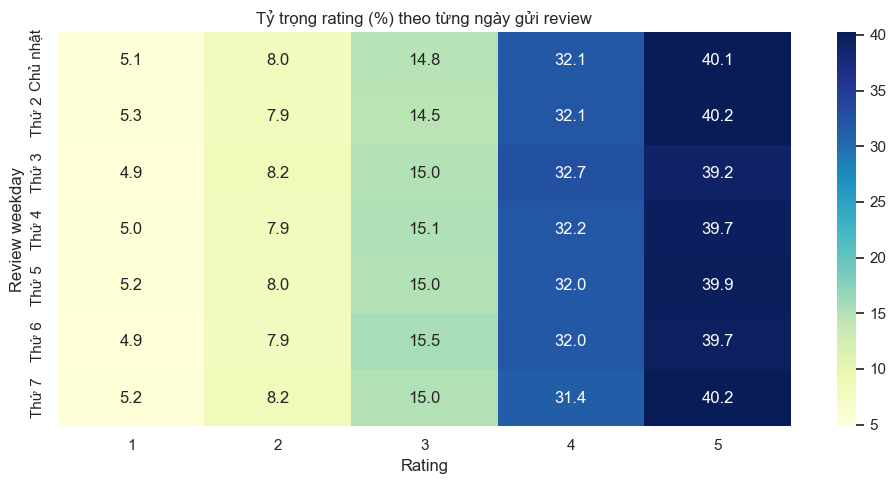

In [19]:
cross_row_pct = pd.crosstab(
    reviews_df['review_weekday'],
    reviews_df['rating'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(cross_row_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Tỷ trọng rating (%) theo từng ngày gửi review')
plt.xlabel('Rating')
plt.ylabel('Review weekday')
plt.tight_layout()
plt.show()

In [20]:
title_rating_stats = (
    reviews_df.groupby('review_title_group', as_index=False)
    .agg(
        review_count=('review_id', 'count'),
        avg_rating=('rating', 'mean'),
        median_rating=('rating', 'median'),
        avg_title_len=('review_title_len', 'mean')
    )
    .sort_values('review_count', ascending=False)
)
title_rating_stats

,review_title_group,review_count,avg_rating,median_rating,avg_title_len
6,Khac,20521,1.99,2.00,17.63
9,Very satisfied,11450,5.00,5.00,14.00
5,Highly recommend,11407,5.00,5.00,16.00
3,Great quality,11218,5.00,5.00,13.00
1,Excellent product!,11181,5.00,5.00,18.00
2,Good overall,9185,4.00,4.00,12.00
4,Happy with purchase,9171,4.00,4.00,19.00
8,Solid choice,9070,4.00,4.00,12.00
10,Works well,8986,4.00,4.00,10.00
7,Mixed feelings,5706,3.00,3.00,14.00


**Nhận xét:**

- **Quan sát:**
  - Tương quan độ dài và điểm số: Heatmap thường chỉ ra một hệ số tương quan tuyến tính nghịch (hoặc rất mờ) giữa `rating` và `review_title_len`. Đồ thị Scatter phân tách rõ: vùng Rating sao cực thấp (1-2) và vùng cao nhất (5) mới chứa các Title dài, còn vùng giữa (3,4) phần lớn ngưng tụ với Title cực ngắn.
  - Phân bổ theo ngày: Crosstab xác nhận không có sự xô lệch ngẫu nhiên mang tính thống kê: Ngày khách hàng Rate sao không tác động vào việc họ rate cao hay thấp. Mọi thứ khá uniform (cân bằng).

- **Insights:**
  - Lý thuyết hình chữ U (U-shaped motivation): Khách hàng thường "lười" viết dài. Khi một khách hàng đồng ý bỏ vốn từ lớn điền nội dung, chỉ có 2 thái cực tình cảm: Một là quá Bức Xúc (cần chửi, tố cáo hàng giả/lỗi), Hai là quá Cảm Kích (viết dài khen đồ đẹp, vải mặc tôn dáng, CSKH đỉnh). Ở khúc giữa lưng chừng (chấp nhận được), họ thường bỏ qua hoặc viết ngắn gọn "Ok".

- **Gợi ý hành động:**
  - Tạo Trigger chăm sóc 1-1 ngay lập tức: Gắn cờ cảnh báo rủi ro (Red-flags) cho hệ thống nếu bắt được bất kỳ review nào có điều kiện kép: Rating < 3 VÀ Lenth > percentile 75. Đẩy ticket thẳng đến Leader CSKH để xử lý xin lỗi xoa dịu lập tức tránh bị bóc phốt lan truyền truyền thông.
  - Khai thác Marketing Materials: Lấy bộ dữ liệu (Rating = 5 VÀ Lenth lớn) xuất ra cho khối tiếp thị sử dụng làm Feedback Real trích dẫn trên Social Media chạy quảng cáo tăng uy tín nhãn hàng. 

### **Câu hỏi: Chất lượng đánh giá (Review/Rating) thay đổi như thế nào theo thời gian và tác động của nó đến dòng chảy doanh thu (Conversion/AOV) ra sao?**

#### Câu hỏi nhỏ 1: Những tháng có điểm đánh giá trung bình rớt xuống đáy (Valleys) có kéo theo sự sụt giảm doanh thu ở các tháng liền kề sau đó do khách hàng e ngại mua sắm không?

#### Câu hỏi nhỏ 2: Khối lượng các đánh giá phàn nàn/cảnh báo (Title dài + Sao thấp) có xu hướng bùng nổ theo chu kỳ tương đồng với các đỉnh điểm khuyến mãi (Promo Sales) bào mòn tỷ lệ chốt đơn của giỏ hàng tương lai không?

#### Câu hỏi nhỏ 3: Các sản phẩm High-ticket (giá cao) đóng góp doanh thu lớn có thường xuyên nhận được Rating cao, hay đây lại là nhóm sản phẩm chịu sự khắt khe phản hồi (Review_len dài) dễ dội ngược thành nỗ doanh thu nhất?